# Scalable Recurrence-Based Feature Extraction for Volatility Regime Prediction
## Reproducibility notebook

**Author:** Nikitas Ttikkou: Bachelor thesis, DACS, Maastricht University
**Supervisors:** Dr. Martijn Boussé · Dr. Philippe Dreesen

---

This notebook reproduces every result, figure, and table in the thesis. It is structured to mirror the thesis chapters. To keep the kernel runtime under a few minutes, **heavy computation loads from precomputed artifacts** in `results/` and `figures/`; the command needed to regenerate each artifact from raw data is shown in a markdown cell directly above it. The reader can run any individual regeneration script independently.

### Layout
1. [Setup & paths](#1.-setup-&-paths)
2. [The three datasets](#2.-the-three-datasets)
3. [Distribution shift across train/test](#3.-distribution-shift-across-train/test)
4. [Recurrence-plot intuition](#4.-recurrence-plot-intuition)
5. [RQA values vs regime — quantitative](#5.-rqa-values-vs-regime-—-quantitative)
6. [Headline classification results](#6.-headline-classification-results)
7. [β-RQA and horizontal measures](#7.-β-rqa-and-horizontal-measures)
8. [Scalable RQA — Marwan 2025](#8.-scalable-rqa-—-marwan-2025)
9. [Aggregation experiment](#9.-aggregation-experiment)
10. [Embedding parameters across timescales](#10.-embedding-parameters-across-timescales)
11. [Walk-forward CV robustness](#11.-walk-forward-cv-robustness)
12. [Summary](#12.-summary)

### Expected runtime
- **With artifacts present:** ~1-2 minutes (this is the default).
- **Regenerating all artifacts:** several hours; see the regeneration commands in each section.


## 1. Setup & paths

Imports, paths, and shared rendering helpers. No computation here.

In [1]:
from pathlib import Path
import warnings
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, Markdown, display

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)


def _find_repo_root() -> Path:
    here = Path.cwd().resolve()
    for candidate in [here, *here.parents]:
        if (candidate / "src" / "scalable_rqa_volatility").exists():
            return candidate
    raise RuntimeError("Could not locate repo root from " + str(here))


REPO = _find_repo_root()
DATA_PROC = REPO / "data" / "processed"
RESULTS = REPO / "results"

FIGS = REPO / "figures"
FIGS_GEN = FIGS / "general_figures"
FIGS_RP = FIGS / "recurrence_plots"
FIGS_FU = FIGS / "checkpoint_followup"

FIGS_GEN.mkdir(parents=True, exist_ok=True)
FIGS_RP.mkdir(parents=True, exist_ok=True)
FIGS_FU.mkdir(parents=True, exist_ok=True)

print(f"Repo root: {REPO}")
print(f"Processed data: {'√' if DATA_PROC.exists() else 'X'} {DATA_PROC}")
print(f"Results:        {'√' if RESULTS.exists() else 'X'} {RESULTS}")
print(f"Figures:        {'√' if FIGS.exists() else 'X'} {FIGS}")
print(f"General figs:   {'√' if FIGS_GEN.exists() else 'X'} {FIGS_GEN}")
print(f"Recurrence:     {'√' if FIGS_RP.exists() else 'X'} {FIGS_RP}")
print(f"Follow-up figs: {'√' if FIGS_FU.exists() else 'X'} {FIGS_FU}")

Repo root: C:\Users\Nikitas Tikkos\Downloads\scalable-rqa-volatility
Processed data: √ C:\Users\Nikitas Tikkos\Downloads\scalable-rqa-volatility\data\processed
Results:        √ C:\Users\Nikitas Tikkos\Downloads\scalable-rqa-volatility\results
Figures:        √ C:\Users\Nikitas Tikkos\Downloads\scalable-rqa-volatility\figures
General figs:   √ C:\Users\Nikitas Tikkos\Downloads\scalable-rqa-volatility\figures\general_figures
Recurrence:     √ C:\Users\Nikitas Tikkos\Downloads\scalable-rqa-volatility\figures\recurrence_plots
Follow-up figs: √ C:\Users\Nikitas Tikkos\Downloads\scalable-rqa-volatility\figures\checkpoint_followup


## 2. The three datasets

Three datasets covering different timescales, sample sizes, and stationarity regimes:

| ID | Source | Frequency | Rows | Tickers | Years |
|----|--------|-----------|------|---------|-------|
| D1 | Core_TimeSeries.csv (synthetic) | daily | 29,990 | 1 | 1902–2017 |
| D2 | S&P 500 macro-financial | daily | 2,265 | 1 | 2010–2019 |
| D3 | Yahoo Finance intraday | 2-min | ≈3M | 503 | last ~60 trading days |

**To regenerate the processed parquets** from the raw CSVs / Yahoo intraday data:
```bash
python scripts/data/run_pipeline.py            
python scripts/data/run_pipeline_dataset2.py   
python scripts/data/run_pipeline_dataset3.py   # Needs sp500_intraday.parquet
```

In [2]:
for ds in (1, 2, 3):
    p = DATA_PROC / f"dataset{ds}_summary.csv"
    if p.exists():
        df = pd.read_csv(p)
        print(f"\nDataset {ds} splits:")
        print(df.to_string(index=False))
    else:
        print(f"Dataset {ds}: summary file missing at {p}")


Dataset 1 splits:
split  rows  regime_mean
train 20986     0.347374
  val  4497     0.306871
 test  4497     0.284189

Dataset 2 splits:
split  rows  regime_mean
train  1571     0.240611
  val   336     0.273810
 test   338     0.334320

Dataset 3 splits:
split    rows  tickers  regime_mean
train 2098289      503     0.239631
  val  449434      503     0.320107
 test  450161      503     0.249433


### Dataset overview plots

Native time series for each dataset showing close price, realized volatility, and the regime label below.

**D1 — synthetic daily**

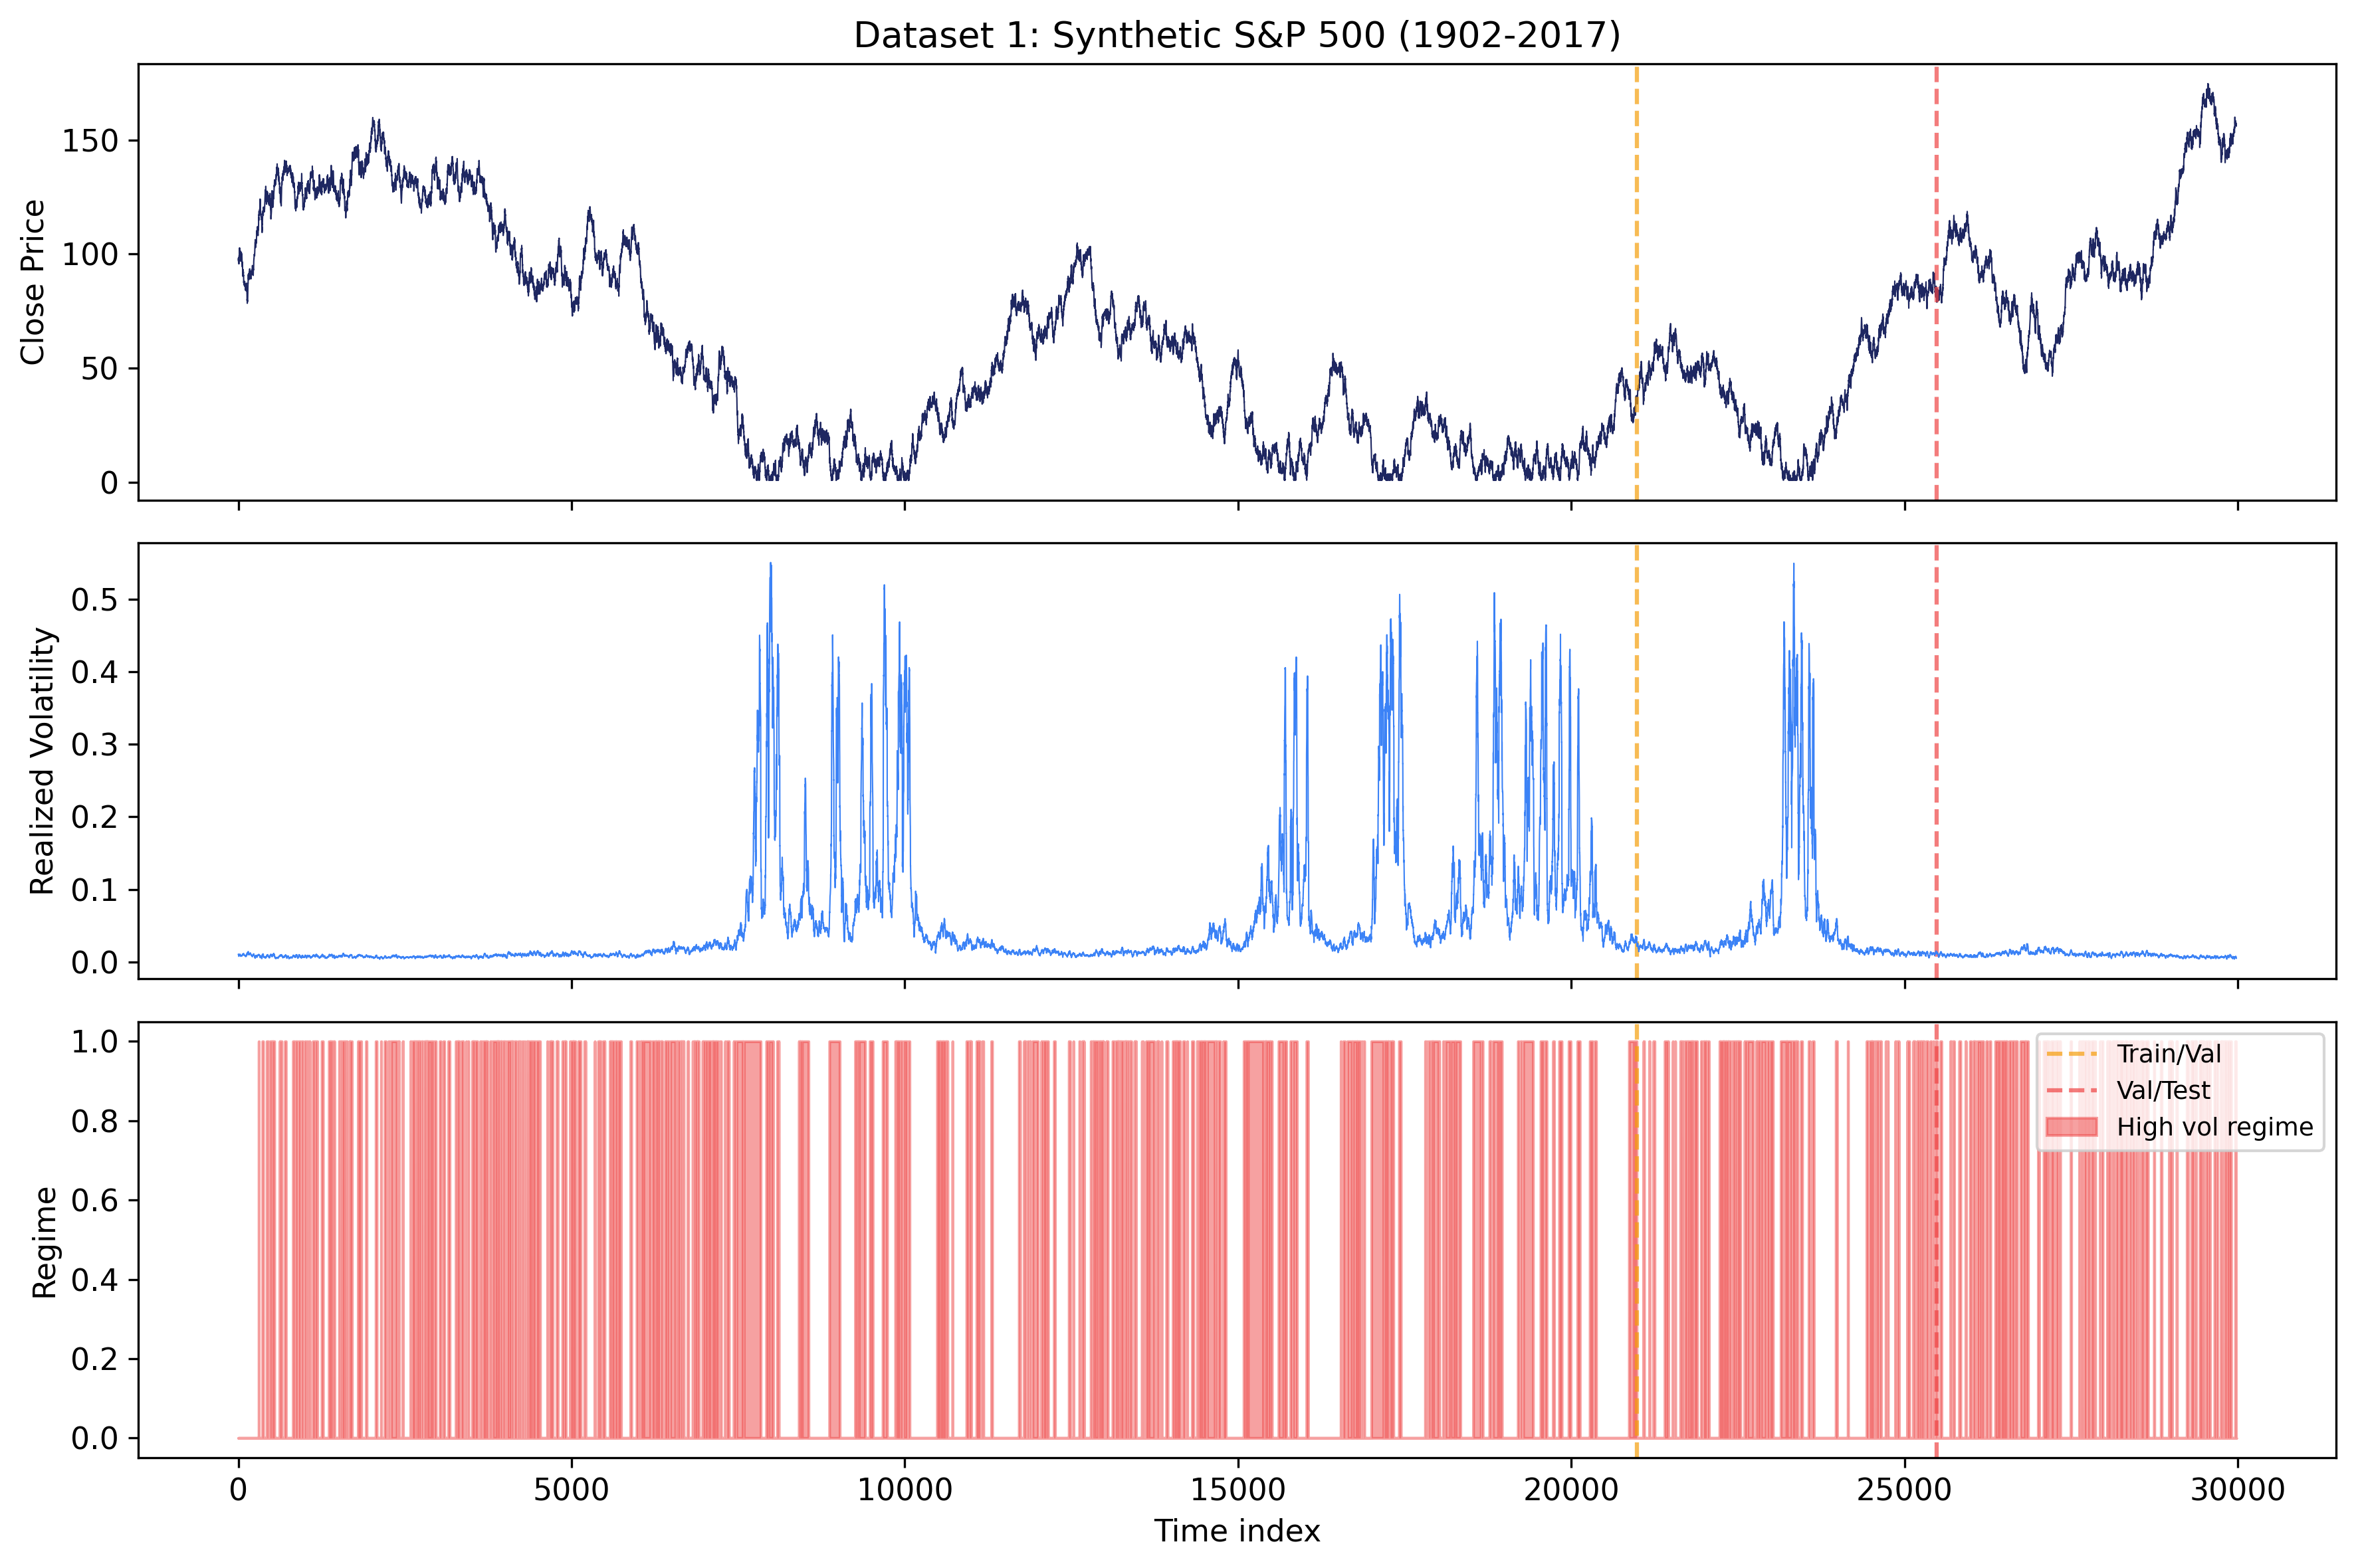

**D2 — S&P 500 macro-financial**

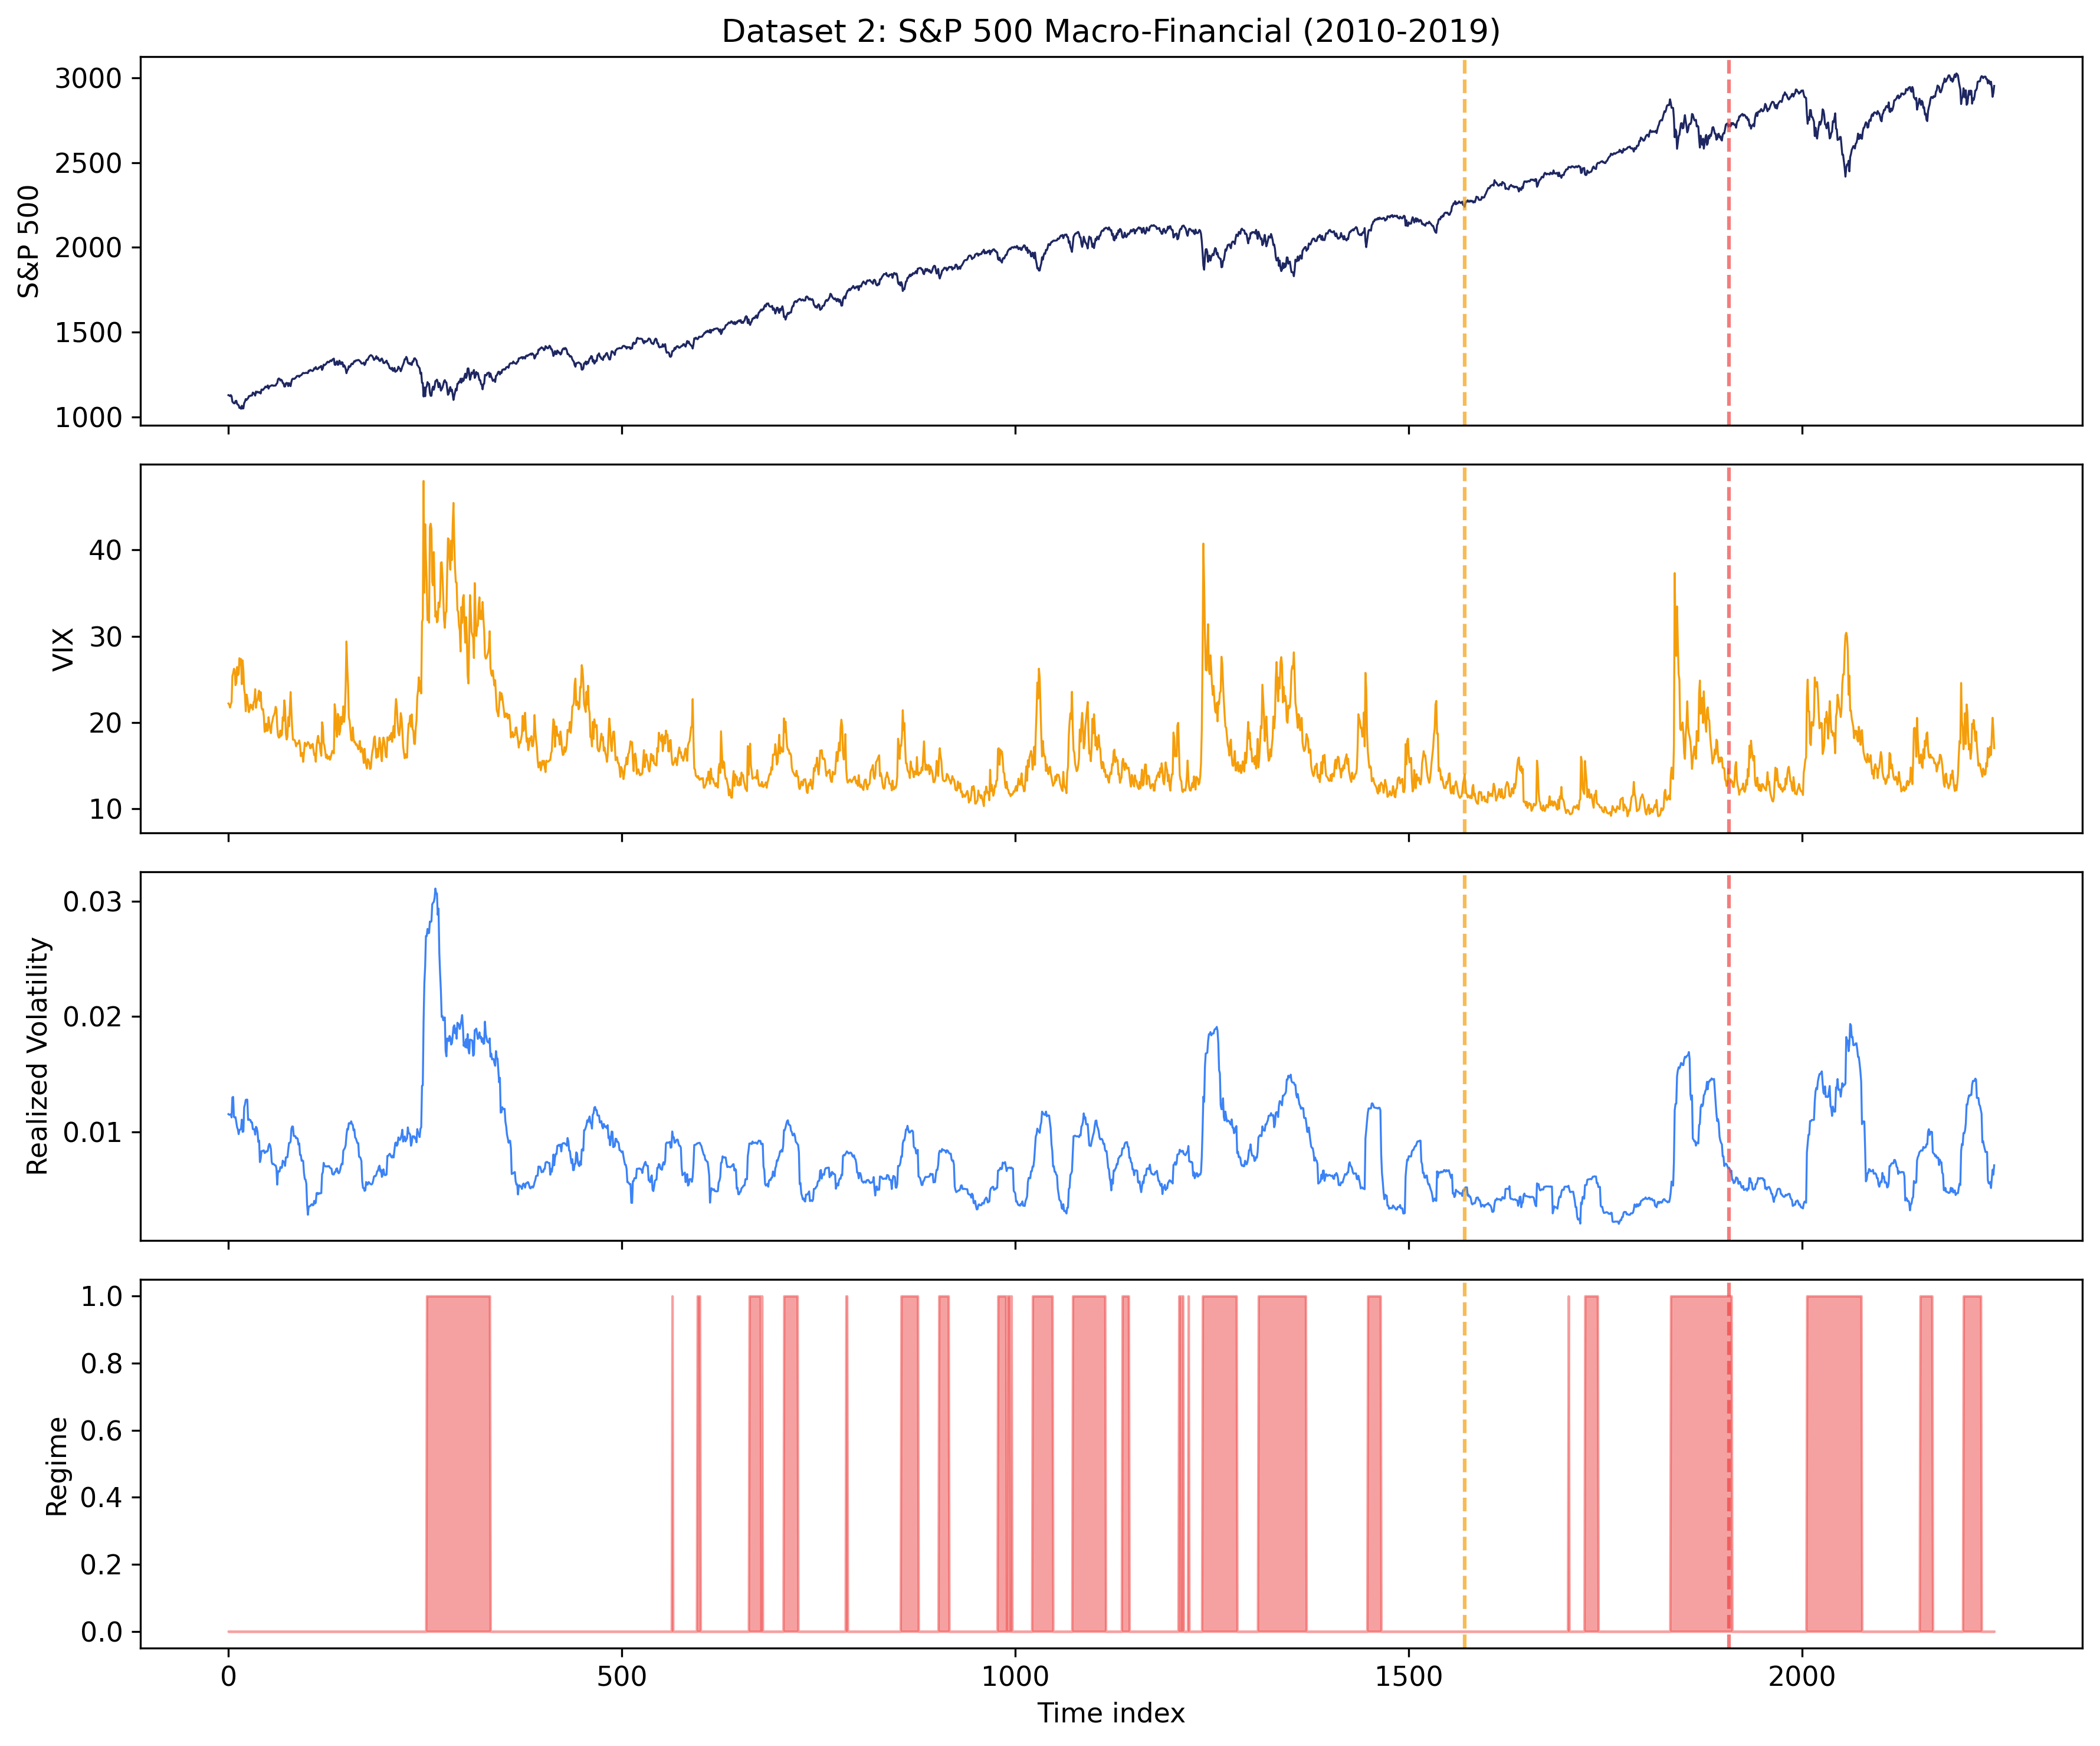

**D3 — intraday panel**

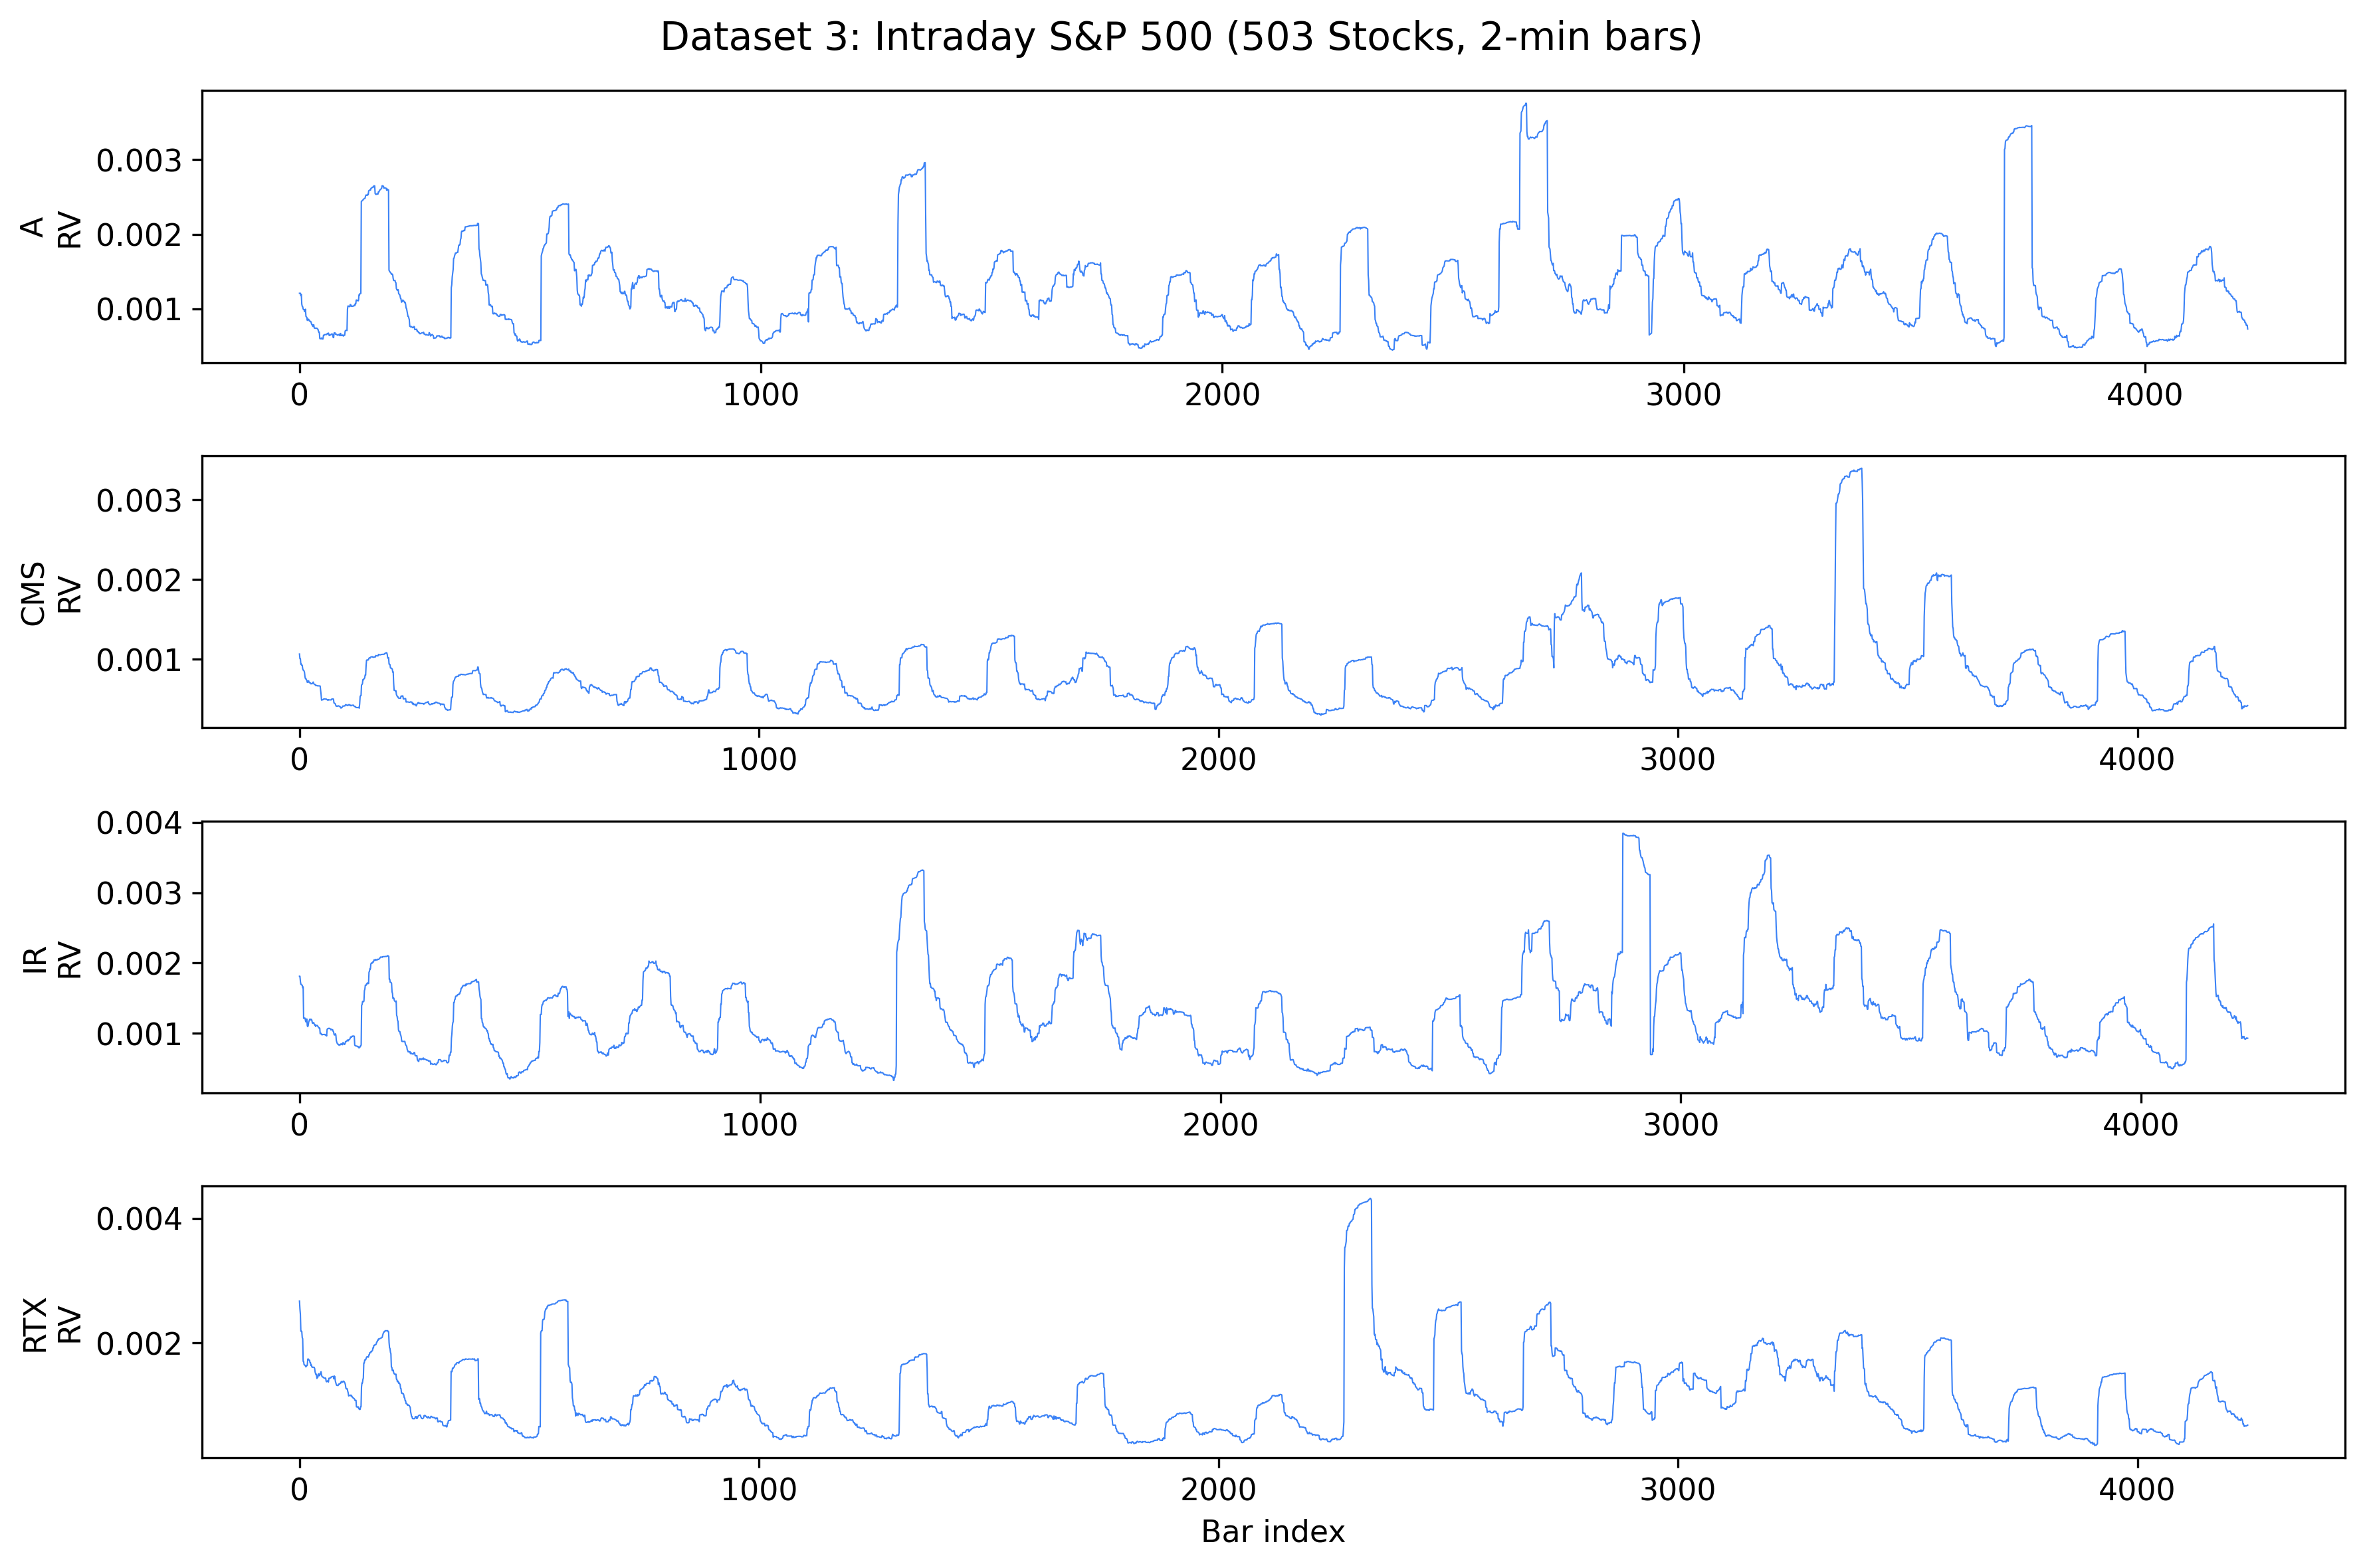

In [3]:
for ds, name in [(1, "D1 — synthetic daily"),
                 (2, "D2 — S&P 500 macro-financial"),
                 (3, "D3 — intraday panel")]:
    p = FIGS_GEN / f"1_{ds}_dataset{ds}_overview.png"
    if p.exists():
        display(Markdown(f"**{name}**"))
        display(Image(filename=str(p), width=900))
    else:
        print(f"Missing: {p} — generate via scripts/visualize/generate_all_figures.py")

## 3. Distribution shift across train/test

The realized-volatility distribution shifts dramatically between train and test on D1 (ratio 0.17×). D2 and D3 are stable (ratios ≈ 1). This is the structural reason RQA effects are not significant on D1, any model there is operating off-distribution.

In [4]:
p = FIGS / "1_4_distribution_shift_comparison.png"
if p.exists():
    display(Image(filename=str(p), width=950))

print("Train→test RV ratio per dataset:")
for ds in (1, 2, 3):
    tr = pd.read_parquet(DATA_PROC / f"dataset{ds}_train.parquet")["rv"].astype(float)
    te = pd.read_parquet(DATA_PROC / f"dataset{ds}_test.parquet")["rv"].astype(float)
    ratio = te.mean() / tr.mean() if tr.mean() > 0 else float("nan")
    print(f"  D{ds}:  train mean = {tr.mean():.5f},  test mean = {te.mean():.5f},  "
          f"ratio = {ratio:.3f}×")

Train→test RV ratio per dataset:
  D1:  train mean = 0.05935,  test mean = 0.01035,  ratio = 0.174×
  D2:  train mean = 0.00844,  test mean = 0.00814,  ratio = 0.965×
  D3:  train mean = 0.00140,  test mean = 0.00133,  ratio = 0.950×


## 4. Recurrence-plot intuition

What an RP actually looks like in low- vs high-volatility regimes on D3 (the dataset where the result lives). All RPs use the project's own RQA library (`src/scalable_rqa_volatility/recurrence/rqa.py`) with `window=60, m=4, τ=2, RR=0.1, mode="joint"` and ε estimated from the training portion of the same ticker, i.e., exactly the configuration the classifier consumes.

**To regenerate:**
```bash
python scripts/visualize/plot_rp_with_regimes.py
```

**fig_a** — Calm vs volatile window, same ticker, same fixed ε. RR jumps from 0.020 to 0.173; ENTR from 0 to 2.07; L_max from 3 to 17.

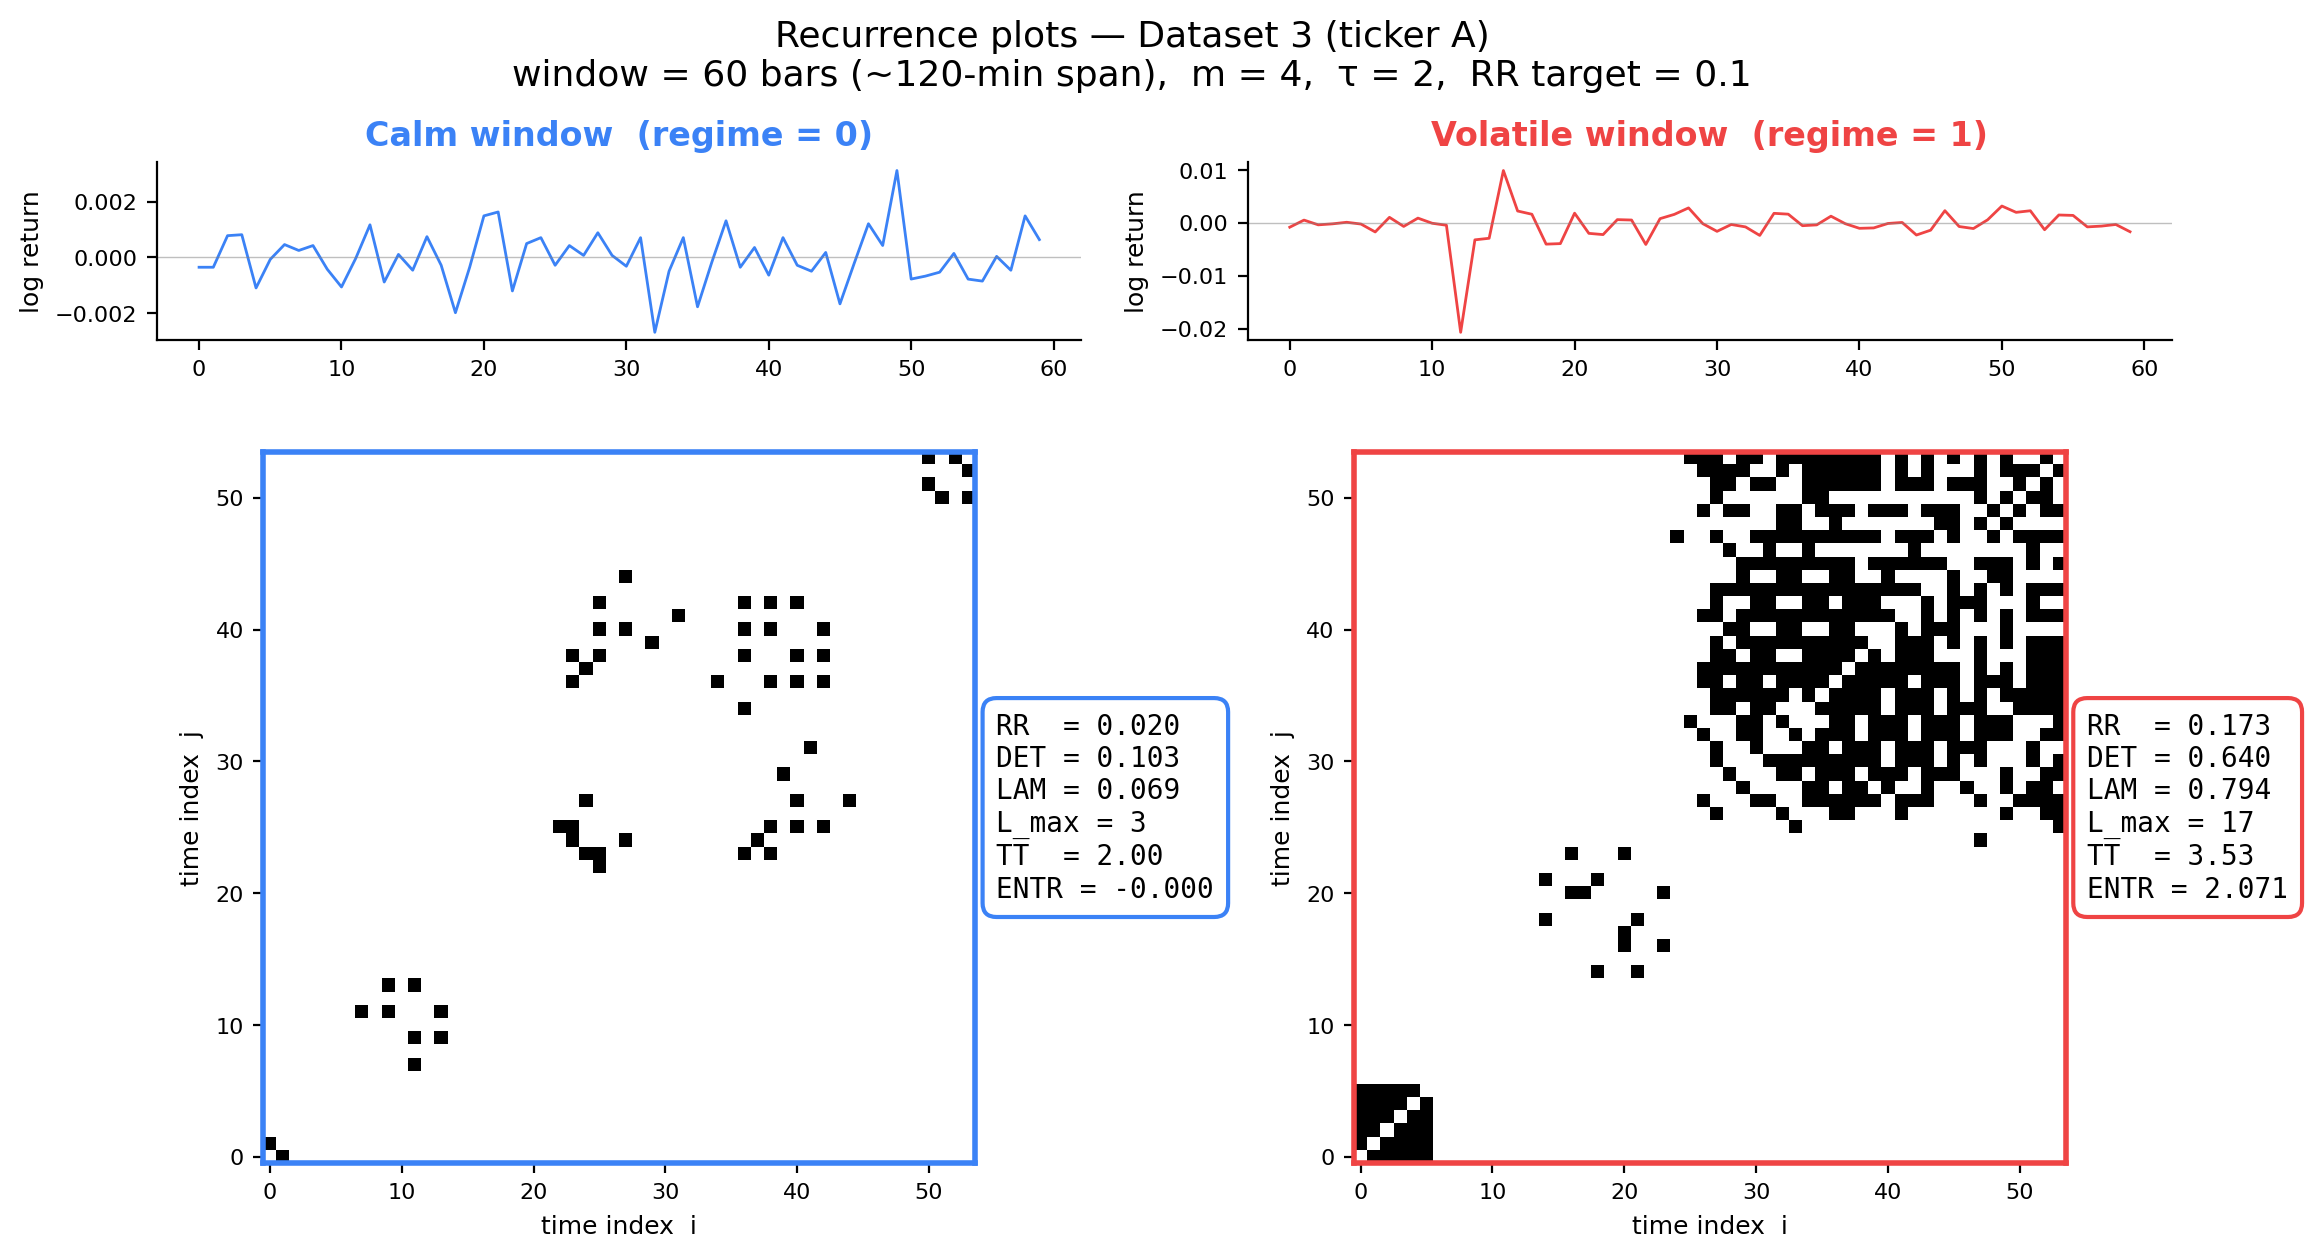

**fig_b** — Long 400-bar RP with regime-shaded axes. Dense recurrence blocks line up with within-regime stretches; empty patches with the high-vol stretch.

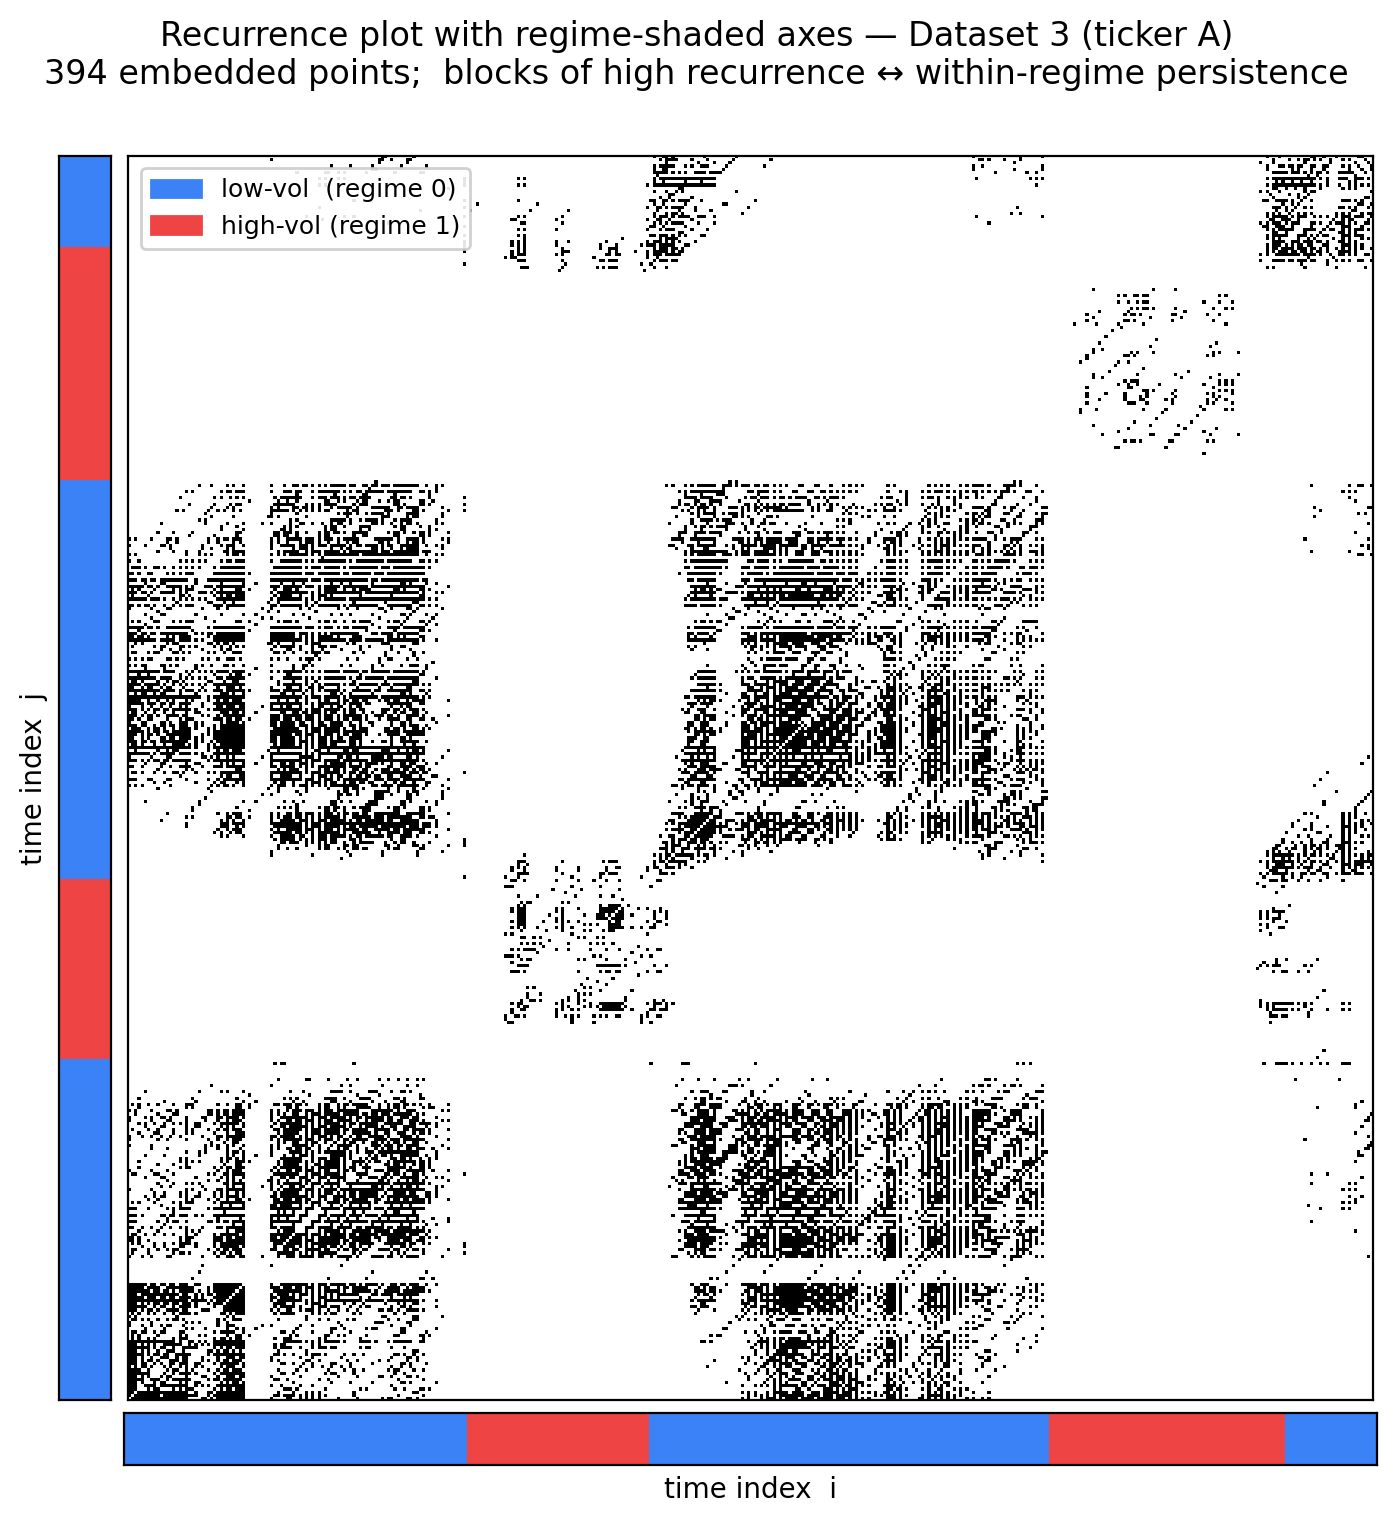

In [5]:
for name, caption in [
    ("fig_a_rp_calm_vs_volatile_d3.png",
     "**fig_a** — Calm vs volatile window, same ticker, same fixed ε. "
     "RR jumps from 0.020 to 0.173; ENTR from 0 to 2.07; L_max from 3 to 17."),
    ("fig_b_rp_with_regime_axes_d3.png",
     "**fig_b** — Long 400-bar RP with regime-shaded axes. "
     "Dense recurrence blocks line up with within-regime stretches; empty patches with the high-vol stretch."),
]:
    p = FIGS_RP / name
    if p.exists():
        display(Markdown(caption))
        display(Image(filename=str(p), width=900))


## 5. RQA values vs regime — quantitative

Boxplots of all six RQA measures split by regime, computed from 1,630 non-overlapping windows across 30 random tickers. Every measure separates the regimes at p < 10⁻⁷ (Mann-Whitney). DET is *higher* in high-volatility windows, a single extreme move in a 60-bar window produces a few extreme embedding vectors that dominate the recurrence structure, creating short repeating diagonals.

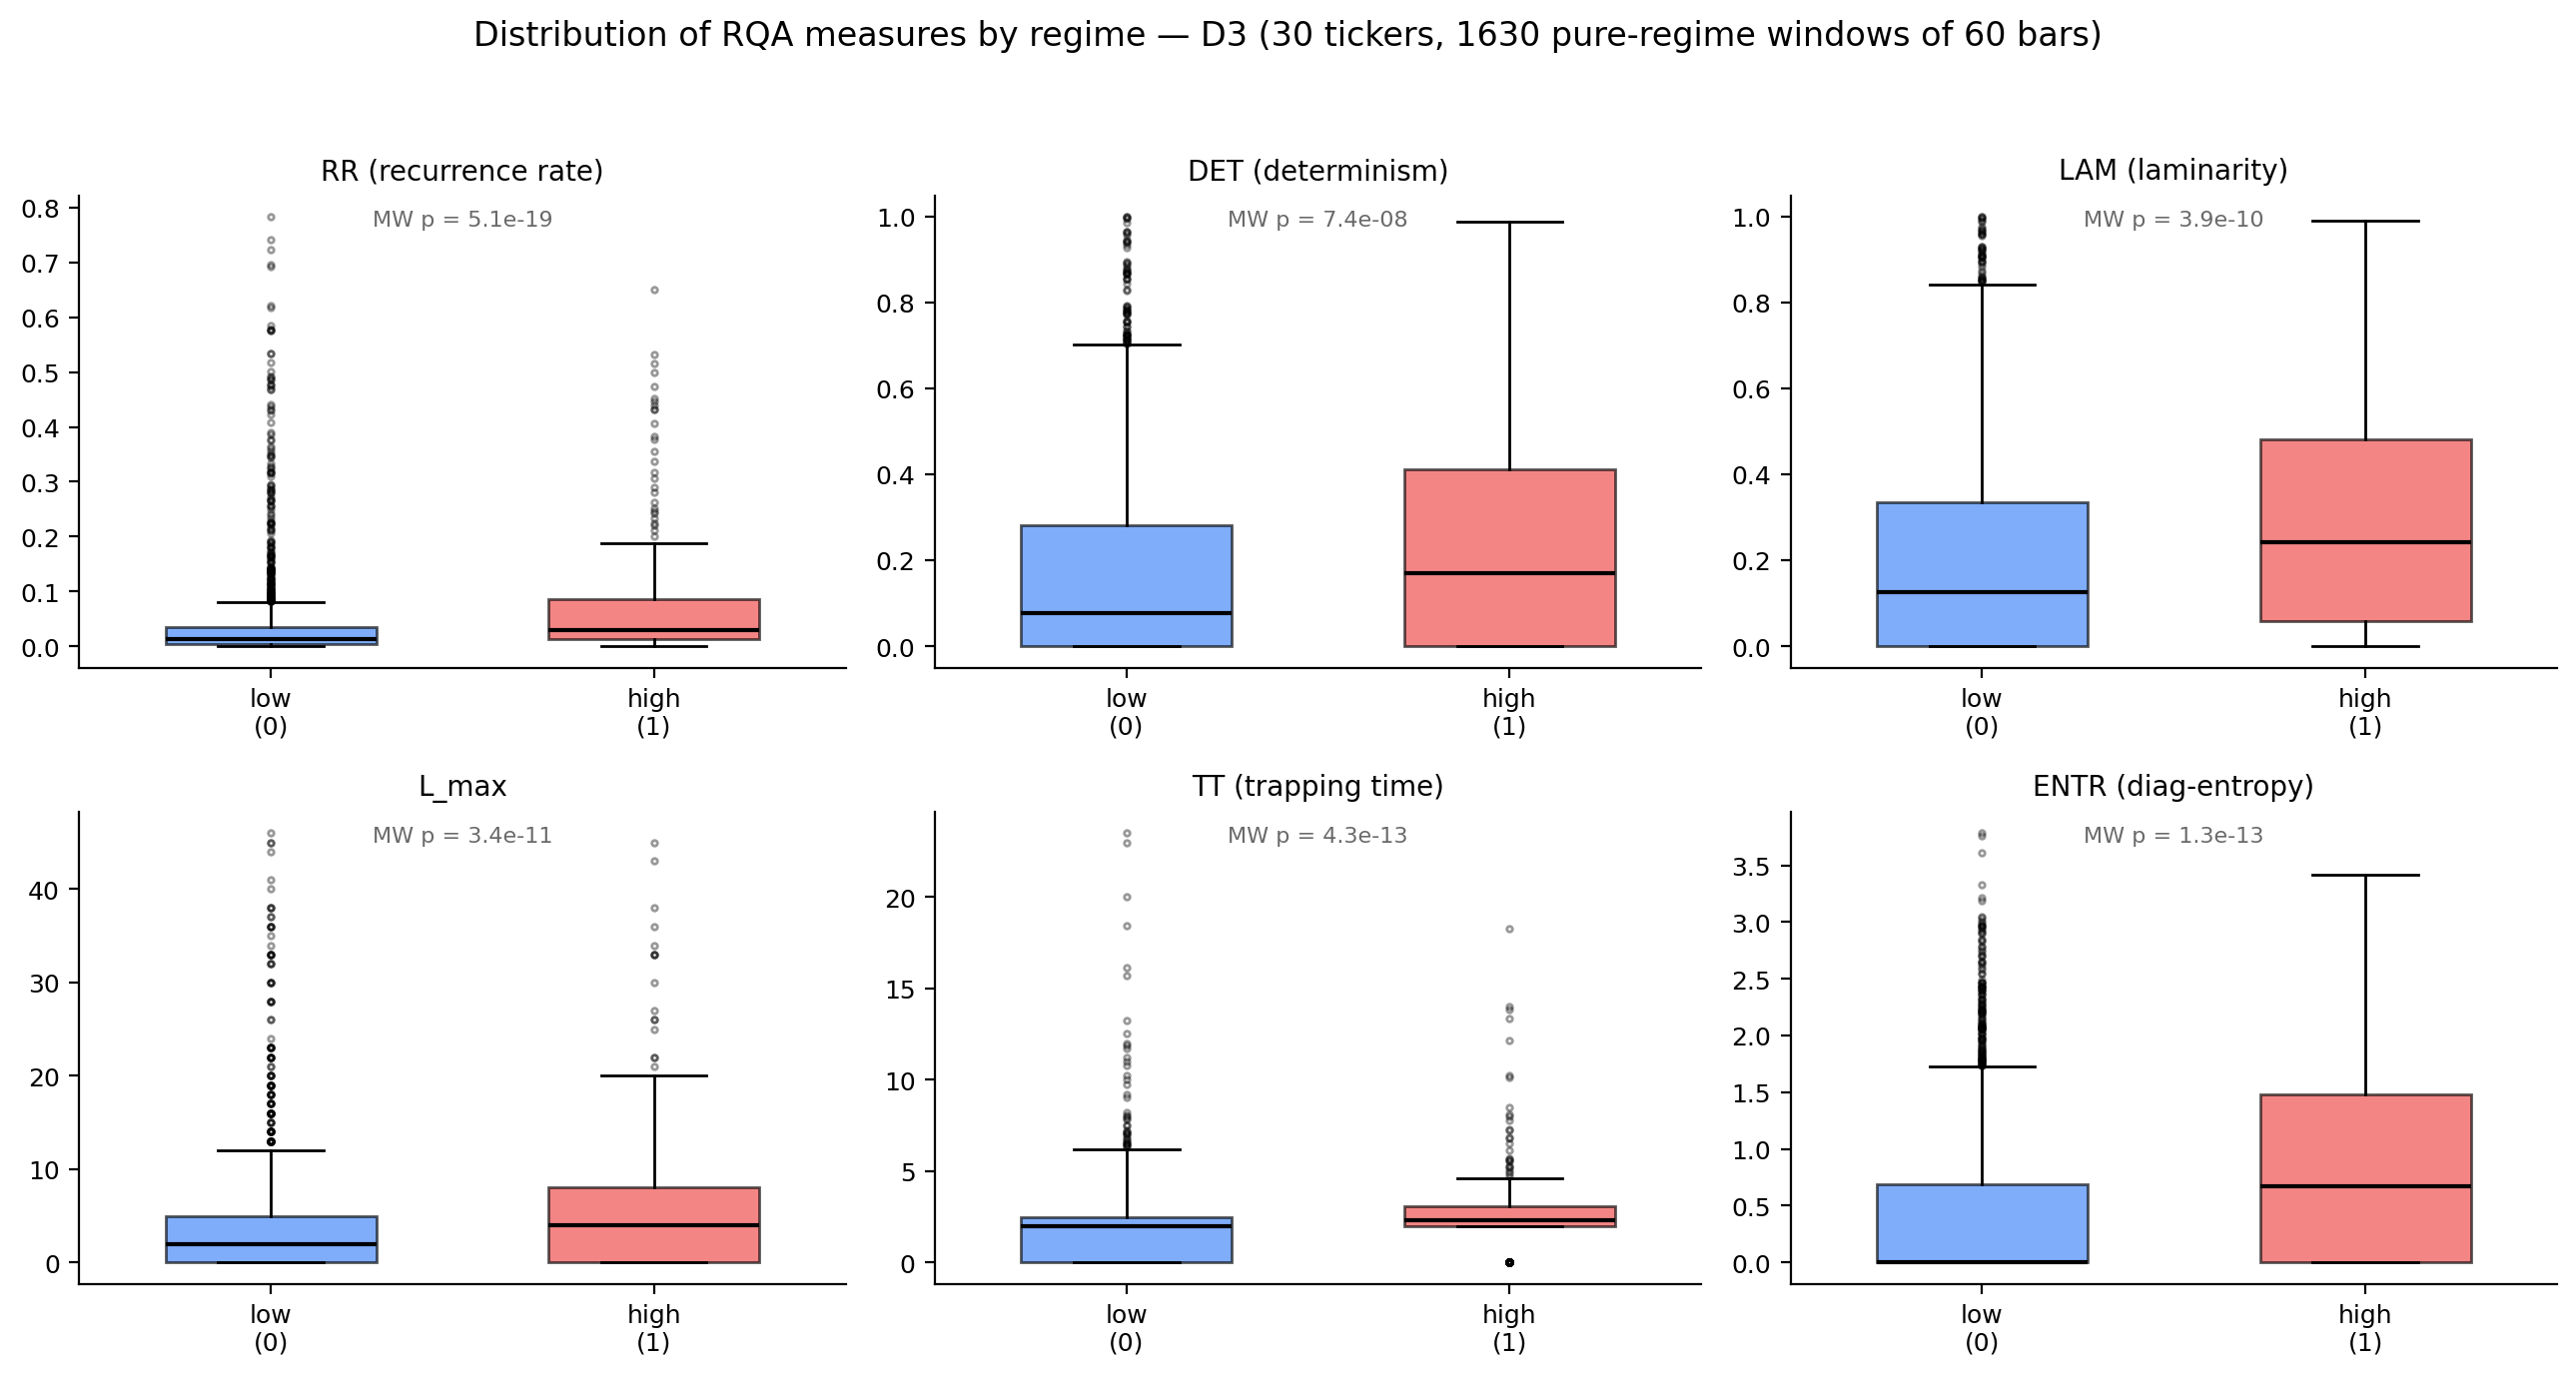

In [6]:
p = FIGS_RP / "fig_c_rqa_distribution_by_regime_d3.png"
if p.exists():
    display(Image(filename=str(p), width=950))

## 6. Headline classification results

Per-stock Random Forest + Logistic Regression with standard features vs standard + RQA vs standard + β-RQA. Tested on the full 503-ticker D3 panel and on D1 and D2 daily series. Statistical tests are paired (Wilcoxon for per-stock metrics; bootstrap CIs pooled across stocks).

**To regenerate:**
```bash
python scripts/evaluate/run_statistical_tests.py --dataset 1
python scripts/evaluate/run_statistical_tests.py --dataset 2
python scripts/evaluate/run_statistical_tests.py --dataset 3
```

In [7]:
for ds in (1, 2, 3):
    p = RESULTS / f"statistical_tests_d{ds}.txt"
    if not p.exists():
        print(f"Missing: {p}")
        continue
    print("=" * 78)
    print(f"D{ds}")
    print("=" * 78)
    text = p.read_text(encoding="utf-8", errors="replace")
    for header in ("A. PER-STOCK METRICS", "A. BOOTSTRAP CONFIDENCE INTERVALS",
                   "B. WILCOXON", "B. PAIRED BOOTSTRAP",
                   "C. BOOTSTRAP CONFIDENCE INTERVALS"):
        m = re.search(rf"^{re.escape(header)}.*?(?=^[A-Z]\.|\Z)",
                      text, flags=re.MULTILINE | re.DOTALL)
        if m:
            block = m.group(0).rstrip()
            print(block)
            print()

D1
A. BOOTSTRAP CONFIDENCE INTERVALS

Model                               AUC           AUC 95% CI       F1            F1 95% CI
------------------------------------------------------------------------------------------
rf_std                           0.8779 [0.8676, 0.8882]   0.6892 [0.6699, 0.7086]
rf_std_rqa                       0.8778 [0.8675, 0.8881]   0.6840 [0.6639, 0.7037]
rf_std_beta                      0.8738 [0.8633, 0.8843]   0.6823 [0.6631, 0.7022]
lr_std                           0.7852 [0.7699, 0.8003]   0.5252 [0.4998, 0.5506]
lr_std_rqa                       0.7744 [0.7582, 0.7897]   0.5020 [0.4754, 0.5276]
lr_std_beta                      0.6904 [0.6729, 0.7069]   0.4531 [0.4276, 0.4775]

B. PAIRED BOOTSTRAP TESTS (AUC difference, H1: B > A)

Comparison                                                 Mean dAUC                 95% CI    p-value
---------------------------------------------------------------------------------------------------------
RF Std → RF Std+R

**One-line summary of the headline:**

| Dataset | RF Std vs RF Std+RQA (paired) | Outcome |
|---------|-------------------------------|---------|
| D1 | ΔAUC = −0.00008, p = 0.539 (paired bootstrap) | n.s. — D1 is off-distribution (see §3) |
| D2 | ΔAUC = −0.020, p = 1.000 | RF+RQA *worse* on D2 — small sample, possibly overfitting RQA features |
| D3 | per-stock ΔAUC = +0.00057, p < 0.001 (Wilcoxon, n=503 tickers) | **significant** — the headline result |

## 7. β-RQA and horizontal measures

Replacing Euclidean distance in the recurrence definition with β-divergence (Deckert et al. (2025)) introduces a tunable asymmetry parameter β. At β = 2 the resulting RP is symmetric and the horizontal-line measures (LAM_h, TT_h, ΔLAM, ΔTT) are mathematically identical to their vertical counterparts. As β moves away from 2 the matrix becomes asymmetric and the horizontal measures carry distinct information.

**Empirical confirmation on D3:**
- At β = 2: LAM ↔ LAM_h correlation = 1.0000, mean |LAM − LAM_h| = 0.0002. Horizontal measures are redundant.
- At β = 1 or β = 4: correlation drops to 0.99 / 0.96. Dropping horizontal measures costs ~10⁻⁴ AUC.

**To regenerate:**
```bash
python scripts/evaluate/feature_importance_beta_sweep_d3.py
```

In [8]:
p = RESULTS / "feature_importance_beta_sweep_d3.txt"
if p.exists():
    text = p.read_text(encoding="utf-8", errors="replace")
    m = re.search(r"A\. SUMMARY ACROSS β VALUES.*?(?=^={3,}|\Z)",
                  text, flags=re.MULTILINE | re.DOTALL)
    if m:
        print(m.group(0).rstrip())
else:
    print(f"Missing: {p}")

A. SUMMARY ACROSS β VALUES

      β   AUC (full)   AUC (no horiz)   Δ (drop horiz)   Horiz perm Σ   Std RQA perm Σ   LAM↔LAM_h corr
  ------------------------------------------------------------------------------------------------------
    0.5     0.983769         0.983767        -0.000002       0.000129         0.000573           0.9769
    1.0     0.983964         0.983763        -0.000201       0.000237         0.000764           0.9852
    1.5     0.983920         0.983819        -0.000100       0.000217         0.000731           0.9929
    2.0     0.983690         0.983835        +0.000144       0.000256         0.000809           1.0000
    3.0     0.983859         0.983898        +0.000039       0.000229         0.000681           0.9825
    4.0     0.983887         0.983783        -0.000104       0.000228         0.000639           0.9579
    5.0     0.983831         0.983828        -0.000003       0.000183         0.000617           0.9312


## 8. Scalable RQA: Marwan 2025

Two scalability tricks from Marwan & Webber 2025:
- **RQA_woRP**: compute RQA without ever constructing the full N×N matrix. Exact, O(N) memory.
- **RQA_Samp**: sample M pairs uniformly and estimate RQA features from the sampled lines. Approximate, O(M) work.

On D3, RQA_Samp with M = 4N gives a ~2× speedup over the exact windowed pipeline at a ΔAUC cost of −0.00015 (Wilcoxon p = 0.019, but the effect size is negligible). M = N or M = 0.2N gives ~3× speedup at −0.00033 ΔAUC, also negligible in practice.

**To regenerate:**
```bash
python scripts/evaluate/benchmark_scalable_rqa.py
python scripts/evaluate/classify_with_rqa_samp_d3.py
```

In [9]:
p = RESULTS / "benchmark_scalable_rqa.txt"
if p.exists():
    print(p.read_text(encoding="utf-8", errors="replace"))
else:
    print(f"Missing: {p}")

  SCALABLE RQA BENCHMARK — DATASET 3
  Methods: Standard (full RP) | RQA_woRP (Marwan 2025) | RQA_Samp (Marwan 2025)


A. SINGLE-STOCK TIMING (stock: IRM, 4216 bars)

       N   Standard       woRP    Samp 4N     Samp N  Samp 0.2N
  ----------------------------------------------------------
      50     0.0036s     0.0021s     0.0015s     0.0000s     0.0015s
     100     0.0062s     0.0057s     0.0031s     0.0015s     0.0000s
     200     0.0087s     0.0118s     0.0045s     0.0015s     0.0000s
     500     0.0307s     0.0345s     0.0178s     0.0056s     0.0016s
    1000     0.0752s     0.1036s     0.0308s     0.0072s     0.0031s
    2000     0.2365s     0.2737s     0.0529s     0.0142s     0.0045s
    3000     0.4433s     0.4638s     0.0568s     0.0148s     0.0030s


B. ACCURACY AT N=3000 (vs exact standard RQA)

  Measure       Exact       woRP    Samp 4N     Samp N  Samp 0.2N
  ----------------------------------------------------------
  rr           0.1125     0.1125     0.1123     0

## 9. Aggregation experiment

**Question (Philippe):** is the RQA gain on D3 genuinely about intraday dynamics, or is it a sample-size effect?

Aggregate D3 from 2-min to 10-min and 30-min bars on a 50-ticker subset, recompute std features at proportionally-scaled windows, and rerun RF Std vs RF Std+RQA.

**Finding (surprising):** the RQA gain *grows* with aggregation:
- 2-min: ΔAUC = −0.0003 (std features ceiling at AUC 0.983)
- 10-min: ΔAUC = +0.0120
- 30-min: ΔAUC = +0.0124

Interpretation: at 2-min the std features already saturate; once they degrade with aggregation, RQA's structural information becomes relatively more valuable. The headline gain is **not** a sample-size artifact.

**To regenerate:**
```bash
python scripts/evaluate/checkpoint_aggregation_and_timescales.py
```

*AUC by bar size, with the ΔAUC effect across aggregation levels.*

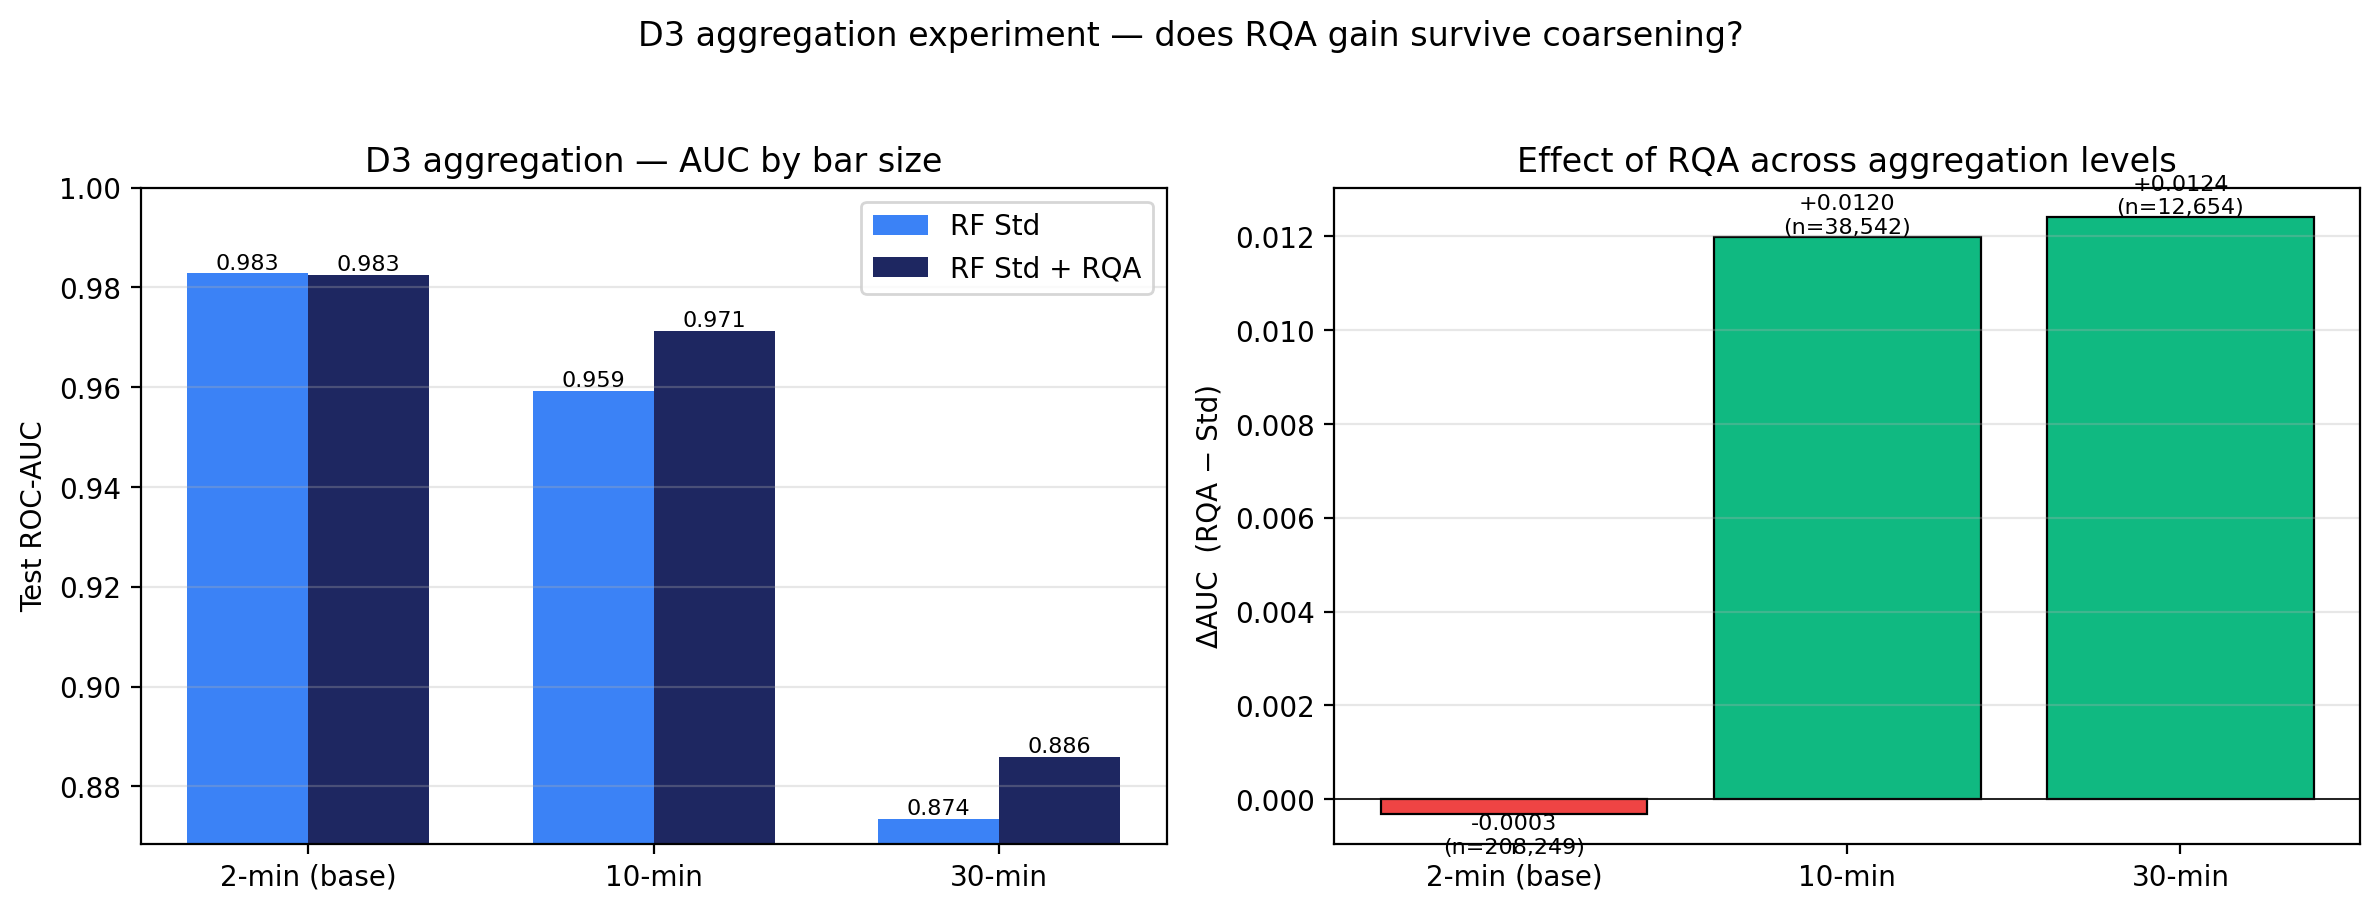

D3 AGGREGATION EXPERIMENT — checkpoint follow-up (item 2)

Random subset: 50 tickers (seed 42)

  Factor      Bar size   Pooled rows     AUC Std    AUC +RQA       ΔAUC     F1 Std    F1 +RQA
-----------------------------------------------------------------------------------------------
       1  2-min (base)       208,249      0.9829      0.9826   -0.00031     0.8734     0.8788
       5        10-min        38,542      0.9593      0.9713   +0.01198     0.8365     0.8516
      15        30-min        12,654      0.8736      0.8860   +0.01240     0.7422     0.7253
  factor=60: insufficient data after aggregation

INTERPRETATION
- If ΔAUC stays positive at all aggregation levels: the RQA gain is
  genuinely about dynamics and survives bar-size changes.
- If ΔAUC trends to zero as bar size grows (sample size shrinks):
  the gain on the full 2-min panel was largely a power effect.



In [10]:
for fig, caption in [
    ("fig_d_d3_aggregation_auc.png",
     "AUC by bar size, with the ΔAUC effect across aggregation levels."),
]:
    p = FIGS_FU / fig
    if p.exists():
        display(Markdown(f"*{caption}*"))
        display(Image(filename=str(p), width=950))

p = RESULTS / "checkpoint_aggregation_d3.txt"
if p.exists():
    print(p.read_text(encoding="utf-8", errors="replace"))

## 10. Embedding parameters across timescales

**Question:** the embedding span (m−1)·τ = 6 covers 6 days on D1 and 6 daily lags but only 12 minutes on D3. Are we comparing comparable things?

**Answer:** autocorrelation of |log returns| has long memory at every frequency. All three datasets stay above ACF = 0.4 well past lag 6. The embedding span of 6 native bars sits inside the strongly-autocorrelated regime regardless of physical time per bar. Backed up empirically by the τ ∈ {1, …, 5} sweep on D3 (AUC flat to 4 decimal places).

**To regenerate:** same script as §9.

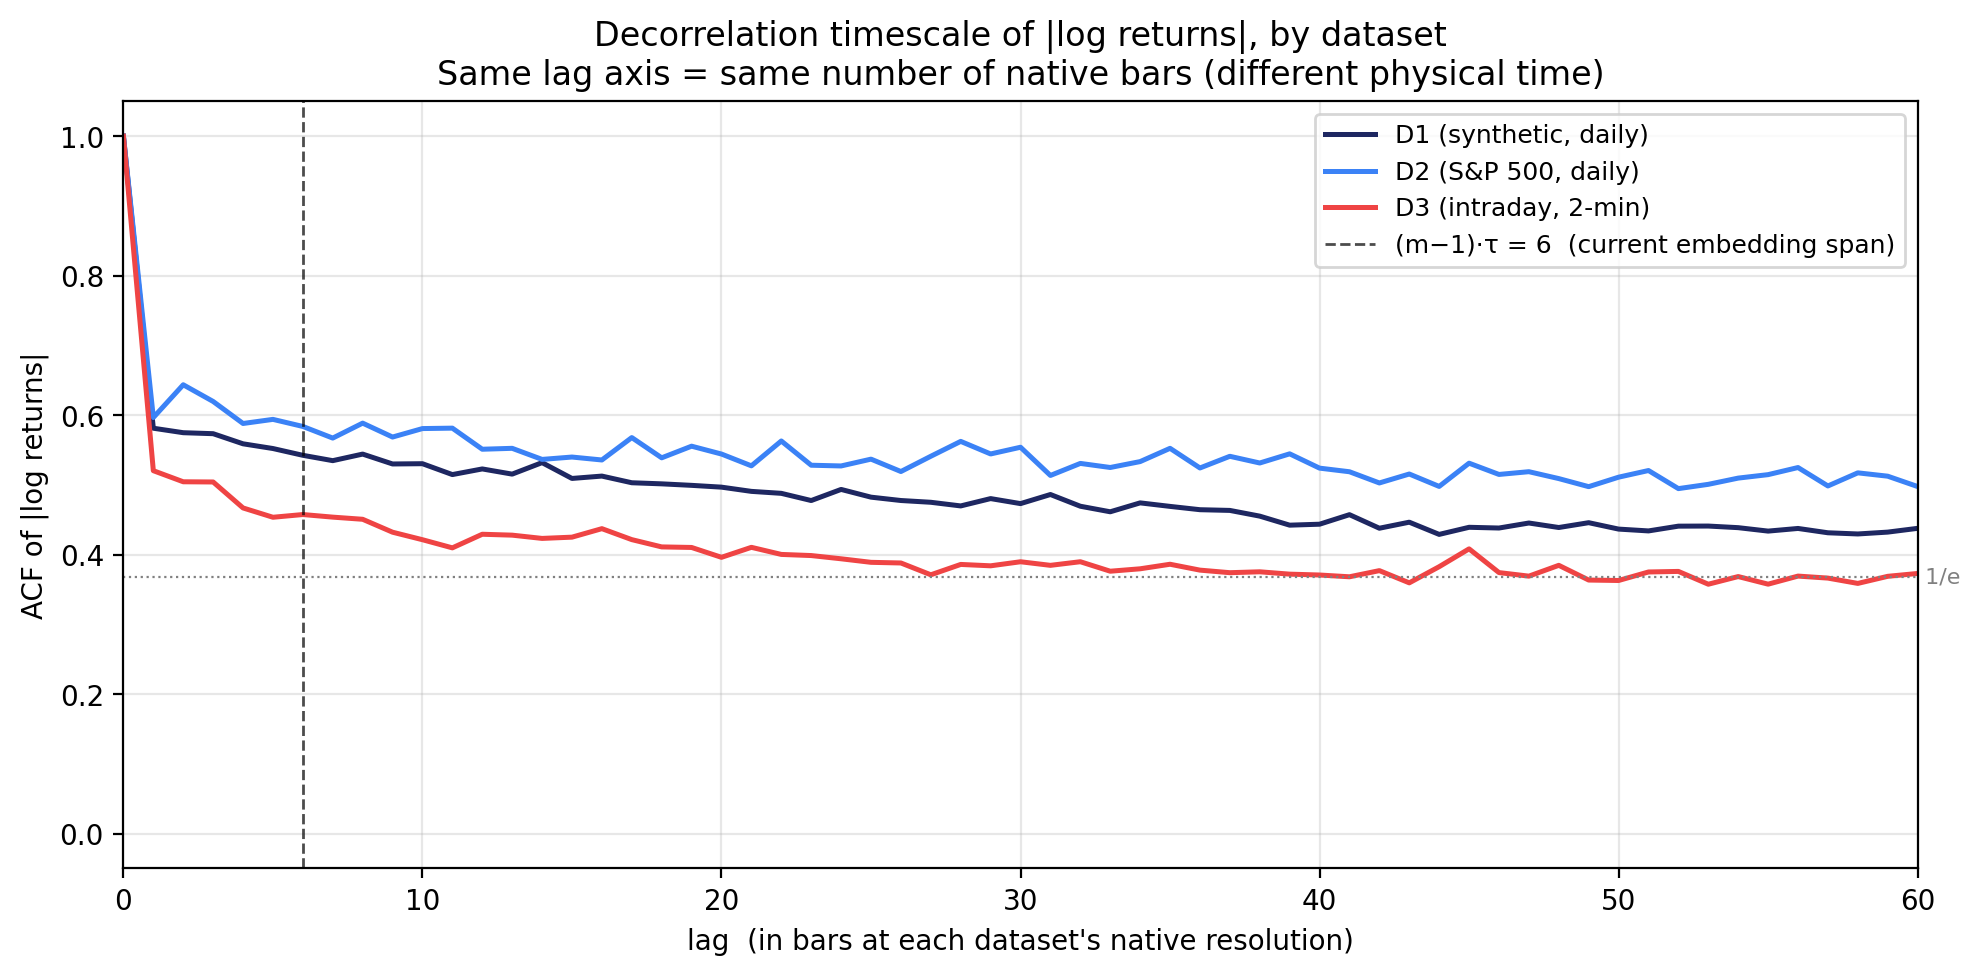

In [11]:
p = FIGS_FU / "fig_e_acf_timescales.png"
if p.exists():
    display(Image(filename=str(p), width=950))

## 11. Walk-forward CV robustness

**Question (Philippe):** chronological 70/15/15 is the textbook default for time series, but is it the strongest possible protocol? Would the result hold under purged walk-forward CV (López de Prado 2018, ch. 7)?

**Protocol:**
- 5 expanding-window forecast origins between 60% and 88% of each ticker's series
- Embargo of 60 bars (= one RV window) between train end and test start
- Purge of 390 bars (= widest std-feature window) — no train observation whose feature span reaches into the test window
- 50-ticker subset, RF Std vs RF Std+RQA, pooled metrics per fold

**Result:**
- Mean ΔAUC across 5 folds = **+0.00176** (SE 0.00027)
- Wilcoxon signed-rank (H₁: ΔAUC > 0): p = 0.03125 (all 5 folds positive)
- Reference: headline single-chronological-split ΔAUC = +0.00057

The RQA gain **survives, and is actually larger** under walk-forward CV than under the single chronological split. This addresses Philippe's concern: the result is not an artifact of the specific 70/15/15 cut point.

**To regenerate:**
```bash
python scripts/evaluate/walk_forward_cv_d3.py            # 50-ticker subset, ~10 min
python scripts/evaluate/walk_forward_cv_d3.py --n_tickers 503   # full panel, ~1 hour
```

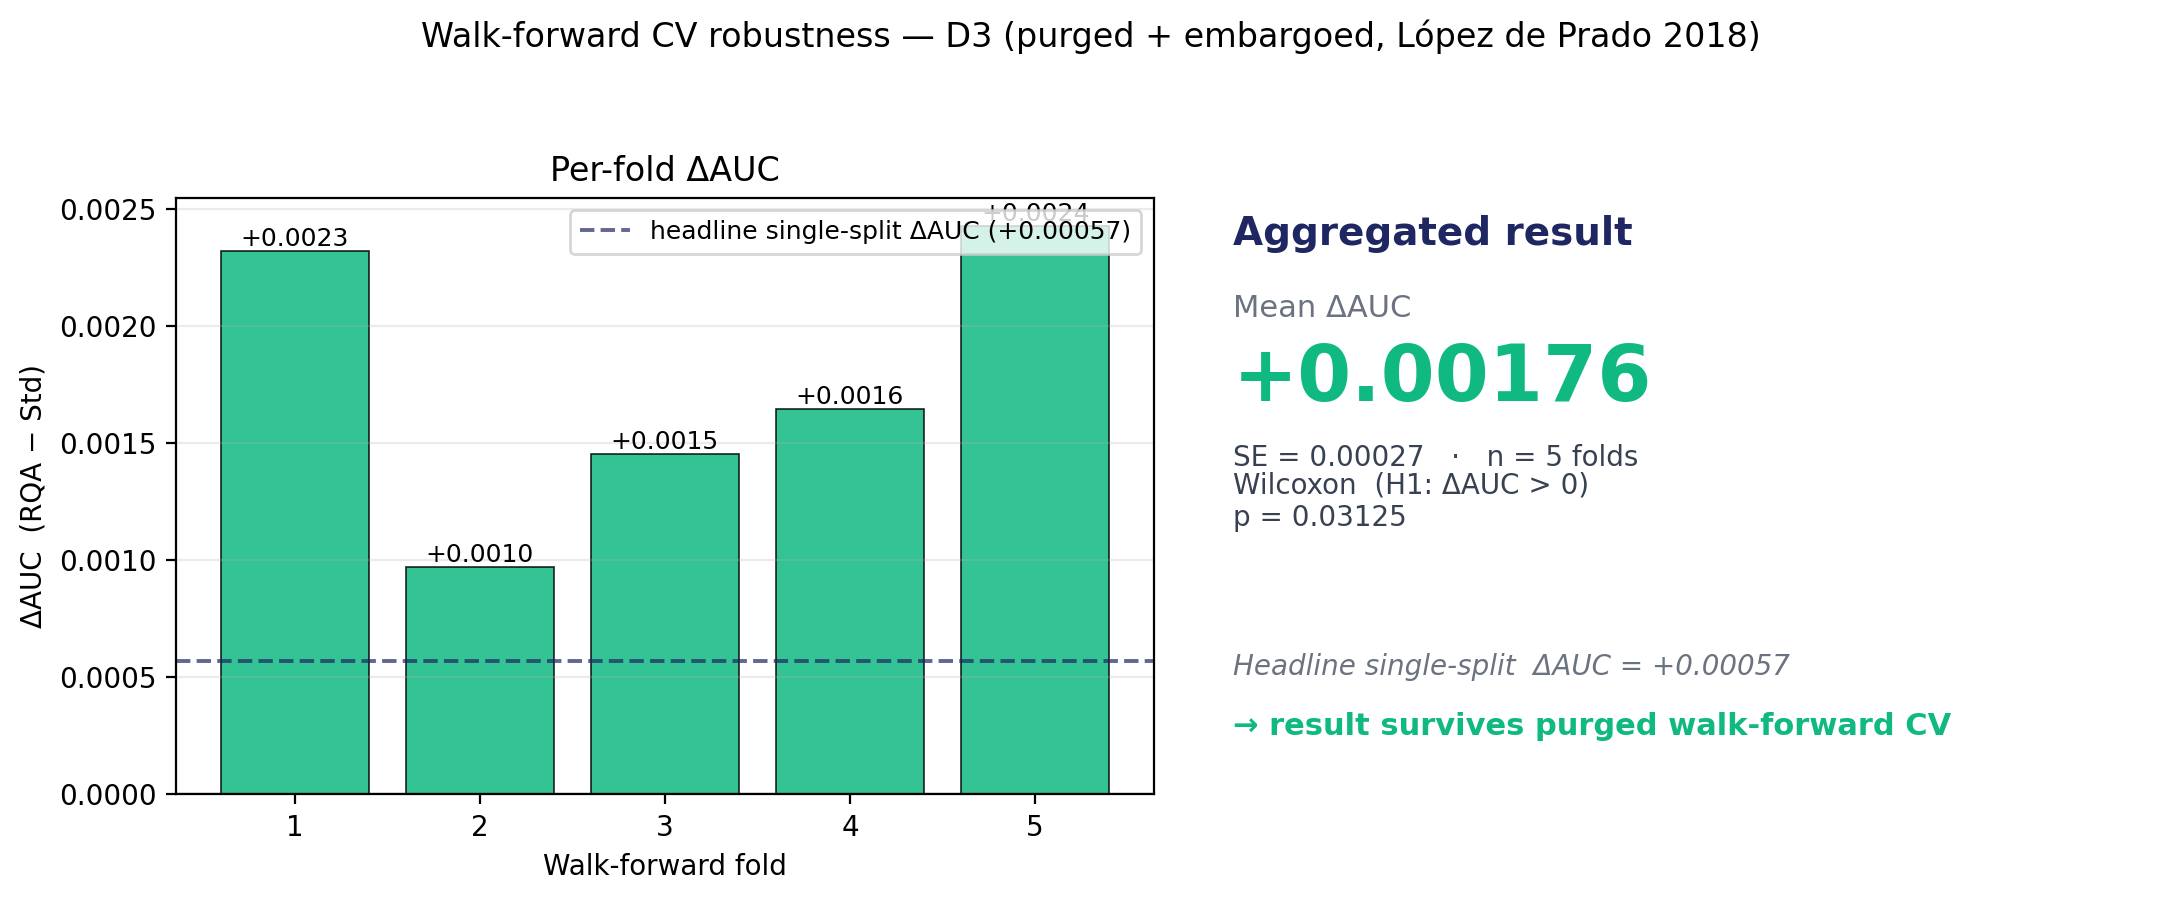

WALK-FORWARD CV ROBUSTNESS — D3

Tickers used: 50 (seed 42)
Folds: 5 expanding-window origins in [0.60, 0.88]
Embargo: 60 bars between train end and test start
Purge horizon: 390 bars
epsilon: 1.07 (estimated from early-period pooled sample)

 Fold   Origin     N_train     N_test    AUC Std    AUC +RQA       ΔAUC
---------------------------------------------------------------------------
    1     0.60     138,532     29,519     0.9646      0.9669   +0.00232
    2     0.67     159,239     29,519     0.9628      0.9638   +0.00097
    3     0.74     179,952     29,519     0.9718      0.9732   +0.00145
    4     0.81     200,669     29,519     0.9733      0.9749   +0.00165
    5     0.88     221,383     29,519     0.9775      0.9799   +0.00243

AGGREGATED
Mean ΔAUC = +0.00176
SE        = 0.00027
n_folds   = 5
Wilcoxon (H1: ΔAUC > 0):  p = 0.03125

Reference: headline single-chronological-split ΔAUC was +0.00057
           (per-stock Wilcoxon p < 0.001, full 503-ticker panel).

INTERPRETAT

In [12]:
p = FIGS_FU / "fig_f_walk_forward_cv_d3.png"
if p.exists():
    display(Image(filename=str(p), width=950))

p = RESULTS / "walk_forward_cv_d3.txt"
if p.exists():
    print(p.read_text(encoding="utf-8", errors="replace"))

## 12. Summary

| Section | Question | Answer |
|---------|----------|--------|
| §3 | Why is D1 not significant? | Severe train→test distribution shift (RV ratio 0.17×). Off-distribution. |
| §4 | What does an RP look like in calm vs volatile regimes? | RR / ENTR / L_max differ by an order of magnitude in the same ticker. |
| §5 | Do RQA values separate the regimes? | All 6 measures, p < 10⁻⁷ (Mann-Whitney). |
| §6 | Headline classification gain on D3? | Per-stock paired ΔAUC = +0.00057, p < 0.001 (Wilcoxon, n = 503). |
| §7 | Does β-RQA help? | Marginal AUC gain on D3; horizontal measures redundant at β = 2 (predicted). |
| §8 | Scalable RQA cost? | 2-3× speedup for negligible (~10⁻⁴) ΔAUC loss. |
| §9 | Is the D3 gain a sample-size effect? | No. Gain grows with aggregation as std features lose their edge. |
| §10 | Are m, τ comparable across timescales? | Yes. |returns| autocorrelation has long memory at every frequency. |
| §11 | Does the gain survive a stricter split protocol? | Yes. Walk-forward mean ΔAUC = +0.00176 > headline +0.00057, p = 0.03125. |

### Caveats and limitations
- **D1 conclusions are weakened by distribution shift.** The dataset's structural design makes it useful as a stress test for off-distribution behavior, not as a primary evaluation.
- **D2 is sample-size-limited.** With n = 338 test observations the per-stock Wilcoxon used for D3 cannot be applied; the paired-bootstrap test on D2 has wide CIs.
- **β-RQA has no scalable variant in the codebase.** RQA_Samp / RQA_woRP (Marwan 2025) only handle Euclidean recurrence. Asymmetric-β (β ≠ 2) remains O(N²), a clear extension point.
- **Walk-forward CV used a 50-ticker subset.** Full-panel rerun (`--n_tickers 503`) is a ~1 hour job; consistent results expected given the per-fold consistency above.

---

*End of reproducibility notebook.*